# Importation et charger les corpus

In [ ]:
from collections import Counter
import spacy
nlp = spacy.load("fr_core_news_sm")

from datasets import load_dataset
dataset = load_dataset("wikimedia/wikipedia", "20231101.fr", split="train", streaming=True)
dataset = dataset.shuffle(seed=42, buffer_size=10000) # 做近似随机打乱, Effectuer un mélange aléatoire approximatif
# 这里对corpus做打乱是为了在读取文章时不要按照顺序提取词语, 防止我们提取到的词语都是同一个thème的

### Observation de la stucture du corpus
在使用dataset之前, 我们先查看一下它的储存结构, 并且看一下是否有一些内容需要被提前清洗 / Avant d'utiliser l'ensemble de données, examinons sa structure de stockage et vérifions si certains contenus doivent être préalablement nettoyés.

In [2]:
iterator = iter(dataset)
article = next(iterator)

# print(type(article)) >>> <class 'dict'>
# print(article.keys()) >>> dict_keys(['id', 'url', 'title', 'text'])
for key, value in article.items():
    print(f"{key} : {value}")

# Deuxième article
article = next(iterator)
for key, value in article.items():
    print(f"{key} : {value}")

id : 12062712
url : https://fr.wikipedia.org/wiki/Archidioc%C3%A8se%20de%20Lecce
title : Archidiocèse de Lecce
text : L' archidiocèse de Lecce (en latin : ) est un archidiocèse métropolitain de l'Église catholique d'Italie appartenant à la région ecclésiastique des Pouilles.

Territoire 
Géographiquement l'archidiocèse se trouve dans une partie de la province de Brindisi et dans la province de Lecce. Son territoire est de  divisé en 77 paroisses regroupées en 4 archidiaconés. Le siège épiscopal est à Lecce où est située la cathédrale de l'Assomption. Dans la même ville se trouve l'église du Gesù qui conserve le corps de saint Bernardin Realino. L'archidiocèse possède 3 basiliques mineures : la basilique de sainte Croix, la basilique Saint Jean-Baptiste et la basilique de Saint Dominique Savio. À Campi Salentina, se trouve le sanctuaire de saint Pompile Marie Pirrotti.

Histoire 

La tradition retrace la fondation du diocèse de Lecce aux temps apostoliques de l'Église, au , Justus de Co

### Nettoyage du corpus
通过观察上面的corpus结构, 我们知道了这个data是一个字典, 每一个article包含其id, url, title, text, 我们之后需要使用的部分是每个article的texte, 但是我们观察到在我们之后需要使用的texte中包含一些除开正文内容之外的结构性内容, 这些是我们不需要的, 所以我们需要进行提前的清洗 / En observant la structure du corpus ci-dessus, nous constatons que ces données se présentent sous la forme d’un dictionnaire. Chaque article contient son identifiant, son URL, son titre et son texte. La partie que nous utiliserons par la suite est le texte de chaque article. Cependant, nous remarquons que les textes dont nous aurons besoin contiennent certains éléments structurels autres que le contenu principal de l’article. Comme ces éléments ne nous sont pas utiles, il est donc nécessaire de procéder à un nettoyage préalable.

需要被清洗的内容如下: / Le contenu suivant doit être nettoyé :
```
Titre
Sources
Voir aussi
Articles liés
Articles connexes
Liens externes
Notes et références
Bibliographie
Annexes
```

In [3]:
import re

def nettoyer_texte_wikipedia(texte):
    sections_a_supprimer = [
        "Notes et références",
        "Références",
        "Sources",
        "Voir aussi",
        "Articles liés",
        "Articles connexes",
        "Liens externes",
        "Bibliographie",
        "Annexes"
    ]

    for section in sections_a_supprimer:
        pattern = r"\n\s*" + re.escape(section) + r"\s*\n"
        match = re.search(pattern, texte, flags=re.IGNORECASE)
        if match:
            texte = texte[:match.start()]
            break

    lignes_propres = []

    for ligne in texte.splitlines():
        ligne = ligne.strip()

        if not ligne: # 删除空行 / Supprimer les lignes vides
            continue

        if ligne.startswith(("-", "*", "•")): # 删除列表项 / Supprimer l'élément de liste
            continue

        if len(ligne.split()) <= 6 and not ligne.endswith((".", "!", "?")): # 删除短标题行：词数少，且不是完整句子 / Supprimez les titres courts : ceux qui contiennent peu de mots et ne sont pas des phrases complètes
            continue

        lignes_propres.append(ligne)

    return " ".join(lignes_propres)

# Choisir les mots polysémies

一直读取 Wikipedia 文章，直到：
至少 50 个名词的频率 >= 200 并且 至少 50 个动词的频率 >= 200

Continuez à lire les articles de Wikipédia jusqu'à ce que nous ayons :
Au moins 100 noms avec une fréquence >= 200 et au moins 100 verbes avec une fréquence >= 200.

In [4]:
# 这个bloc运行大概需要3分钟
# Ce bloc prendra environ 3 minutes à s'exécuter

noun_counter = Counter()
verb_counter = Counter()

for article in dataset:
    texte = nettoyer_texte_wikipedia(article["text"])
    texte = nlp(texte)

    for mot in texte:
        if mot.is_alpha and not mot.is_stop and len(mot.text) >= 4:
            lemma = mot.lemma_.lower()

            if mot.pos_ == "NOUN":
                noun_counter[lemma] += 1

            elif mot.pos_ == "VERB":
                verb_counter[lemma] += 1

    if (
        sum(1 for freq in noun_counter.values() if freq >= 200) >= 50
        and sum(1 for freq in verb_counter.values() if freq >= 200) >= 50
    ):
        break

frequent_nouns = [(word, freq) for word, freq in noun_counter.most_common()][:50]

frequent_verbs = [(word, freq) for word, freq in verb_counter.most_common()][:50]

In [5]:
print("=== 50 noms fréquents, fréquence >= 200 ===")
for word, freq in frequent_nouns:
    print(word, freq)

=== 50 noms fréquents, fréquence >= 200 ===
année 1279
partie 918
ville 815
région 752
commune 749
film 749
membre 726
femme 714
état 682
guerre 672
titre 651
groupe 650
université 647
famille 638
cours 604
saison 593
ligne 580
rivière 578
équipe 556
homme 552
église 541
fois 516
espèce 506
série 502
place 498
début 489
service 484
mort 482
nord 473
suite 470
pays 464
centre 456
lieu 455
temps 449
jour 443
site 434
département 433
travail 432
société 423
localité 423
système 421
président 415
histoire 415
point 413
monde 407
prix 398
étude 392
championnat 386
fils 383
enfant 380


In [6]:
print("=== 50 verbes fréquents, fréquence >= 200 ===")
for word, freq in frequent_verbs:
    print(word, freq)

=== 50 verbes fréquents, fréquence >= 200 ===
situer 1066
devenir 839
utiliser 621
trouver 615
prendre 580
créer 513
partir 490
réaliser 482
publier 447
recevoir 426
connaître 425
sortir 405
passer 404
faire 400
mourir 400
remporter 387
obtenir 377
nommer 360
travailler 353
donner 336
commencer 327
permettre 321
composer 319
appeler 313
construire 301
comprendre 275
mettre 273
produire 263
rejoindre 255
porter 253
présenter 248
considérer 246
écrire 244
pouvoir 243
représenter 242
agir 240
atteindre 238
constituer 233
compter 233
voir 226
découvrir 224
fonder 223
former 223
déclarer 219
organiser 217
diriger 215
jouer 213
venir 203
installer 200
présente 200


## Mots choisis & Collections des contextes des mots
根据上面随机提取的出现频率较高的词语, 我们从中选取了一些mots polysémies作为我们的研究对象, 以下是liste des mots choisis, 并且给每一个词语收集了一些上下文contexte, 储存方式如下:
```
{   
    "mot1":[phrase1, phrase2..., phrase100], 
    "mot2":[phrase1, phrase2..., phrase100], 
    ...
    "mot20":[phrase1, phrase2..., phrase100]
    }
```

In [6]:
# 这个bloc运行大概需要2分钟左右
# Ce bloc prendra environ 2 minutes à s'exécuter

mots_polysemies = [
    'site','partie','histoire','titre','état','ligne','place','service','cours','point',
    'trouver','prendre','partir','sortir','passer','faire','donner','appeler','comprendre','mettre'
    ]


contextes = {mot: [] for mot in mots_polysemies} # 创建字典：每个词对应一个空列表，用来存放上下文句子 / Dictionnaire : chaque mot correspond à une liste vide utilisée pour stocker la phrase de contexte.

phrases_deja_vues = {mot: set() for mot in mots_polysemies} # 用来避免同一个词收集到重复句子 / Pour éviter de répéter le même mot dans des phrases

for article in dataset:
    texte = nettoyer_texte_wikipedia(article["text"])
    texte = nlp(texte)

    for phrase in texte.sents:
        tokens = [token for token in phrase if not token.is_space] # 计算句子的 token 数量 / Calculer le nombre de token dans une phrase

        if len(tokens) < 10 : # or len(tokens) > 50: # 只保留长度在 10 tokens 以上的句子 / Garder les phrases qui ont plus de 10 tokens
            continue

        phrase_texte = phrase.text.strip()
    
        for token in phrase:
            lemma = token.lemma_.lower()

            if lemma in mots_polysemies: # 检查这句话里出现了哪些 target mots / Vérifier s'il y a un mot ciblé apparaissent dans cette phrase.
                mot = lemma

                if len(contextes[mot]) >= 200: # 如果这个词已经有 200 个句子了，就不再收集 / Si ce mot compte déjà 200 contexte, il ne sera plus collecté
                    continue

                if phrase_texte in phrases_deja_vues[mot]: # 如果这个句子之前已经为这个词收集过，就跳过 / Ignorer cette phrase si elle a déjà été collectée pour ce mot
                    continue

                contextes[mot].append(phrase_texte)
                phrases_deja_vues[mot].add(phrase_texte)

        if all(len(contextes[mot]) >= 200 for mot in mots_polysemies): # 如果所有词都已经有 200 个句子，就停止 / Arrêter s'il y a déjà 200 phrases contenant tous les mots
            break

    if all(len(contextes[mot]) >= 200 for mot in mots_polysemies):
        break

In [7]:
for mot in mots_polysemies:
    print(f'================= {mot} =================')
    for phrase in contextes[mot][:5]:
        print("-", phrase)

================= site =================
- À la convention , organisée en novembre à San Francisco, la démo fait à nouveau mouche et Colin Campbell du site Polygon y voit un jeu qui s'approche de l'excellence.
- Pour recruter autant de doubleurs différents, alors qu'il a jusque-là avancé tout seul sur le jeu, Lucas Pope fait passer des auditions sur le site  et fait ensuite vérifier l'authenticité de chaque candidature à des amis de la même nationalité d'origine.
- pour le site américain, ces détails soignés par Lucas Pope font partie des meilleures mécaniques de jeu de l'année.
- Le site regrette aussi la possibilité de « tricher » offerte au joueur lorsque, si l'on est sûr de la mort de deux personnages, on avance une troisième identité au hasard.
- En , le site d'estimations  considère qu'il existe entre  et  propriétaires du jeu sur .
================= partie =================
- Géographiquement l'archidiocèse se trouve dans une partie de la province de Brindisi et dans la province

## BERT向量 + 多义

In [8]:
# =========================
# 1. Imports
# =========================

import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from transformers import AutoTokenizer, AutoModel

# UMAP 可选；如果环境里没有，就自动用 t-SNE
try:
    from umap import UMAP
    UMAP_DISPONIBLE = True
except ImportError:
    UMAP_DISPONIBLE = False
    print("UMAP n'est pas installé. Le code utilisera t-SNE à la place.")


In [ ]:
# =========================
# 3. Chargement de CamemBERT
# =========================

model_name = "camembert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

In [11]:
# =========================
# 4. Extraction de l'embedding contextualisé
# =========================

def get_embedding_mot_dans_phrase_par_lemme(phrase, lemme_cible):
    """
    Retourne l'embedding contextualisé du mot dont le lemme correspond à lemme_cible.
    On utilise la moyenne des 4 dernières couches de CamemBERT.
    """

    doc = nlp(phrase)
    positions = []

    for token in doc:
        
        if token.lemma_.lower() == lemme_cible.lower():
            char_start = token.idx
            char_end = token.idx + len(token.text)
            positions.append((char_start, char_end, token.text))

    if len(positions) == 0:
        return None, None

    # Si le mot apparaît plusieurs fois dans la phrase, on prend la première occurrence.
    char_start, char_end, forme_trouvee = positions[0]

    encoded = tokenizer(
        phrase,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=128
    )

    offsets = encoded["offset_mapping"][0].tolist()
    encoded_sans_offsets = {
        k: v.to(device)
        for k, v in encoded.items()
        if k != "offset_mapping"
    }

    token_indices = []

    for i, (start, end) in enumerate(offsets):
        if start == end == 0:
            continue

        # Le sous-token chevauche l'occurrence du mot cible.
        if start < char_end and end > char_start:
            token_indices.append(i)

    if len(token_indices) == 0:
        return None, None

    with torch.no_grad():
        outputs = model(**encoded_sans_offsets, output_hidden_states=True)

    # Moyenne des 4 dernières couches
    last_four_layers = outputs.hidden_states[-4:]
    stacked = torch.stack([layer[0] for layer in last_four_layers])
    hidden_states = stacked.mean(dim=0)

    # Moyenne des sous-tokens du mot cible
    word_embedding = hidden_states[token_indices].mean(dim=0)

    return word_embedding.cpu().numpy(), forme_trouvee

In [12]:
# =========================
# 5. Calcul des embeddings pour chaque mot
# =========================

# 这个bloc运行大概需要3分钟左右
# Ce bloc prendra environ 3 minutes à s'exécuter

embeddings_par_mot = {}
phrases_valides_par_mot = {}
formes_trouvees_par_mot = {}

for mot in mots_polysemies:
    phrases = contextes[mot]

    vecteurs = []
    phrases_valides = []
    formes_trouvees = []

    for phrase in tqdm(phrases, desc=f"Embedding : {mot}"):
        vec, forme = get_embedding_mot_dans_phrase_par_lemme(phrase, mot)

        if vec is not None:
            vecteurs.append(vec)
            phrases_valides.append(phrase)
            formes_trouvees.append(forme)

    embeddings_par_mot[mot] = np.array(vecteurs)
    phrases_valides_par_mot[mot] = phrases_valides
    formes_trouvees_par_mot[mot] = formes_trouvees

    print(f"{mot:12s} -> {len(vecteurs)} embeddings trouvés")

Embedding : site: 100%|██████████| 200/200 [00:08<00:00, 24.26it/s]


site         -> 200 embeddings trouvés


Embedding : partie: 100%|██████████| 200/200 [00:07<00:00, 25.28it/s]


partie       -> 200 embeddings trouvés


Embedding : histoire: 100%|██████████| 200/200 [00:07<00:00, 25.30it/s]


...

appeler      -> 199 embeddings trouvés


Embedding : comprendre: 100%|██████████| 200/200 [00:07<00:00, 26.86it/s]


comprendre   -> 199 embeddings trouvés


Embedding : mettre: 100%|██████████| 200/200 [00:07<00:00, 27.03it/s]

mettre       -> 200 embeddings trouvés


In [13]:
# =========================
# 6. Score de polysémie basé sur les similarités cosinus
# =========================

def score_polysemie(X):
    """
    Score de polysémie = écart-type des similarités cosinus deux à deux.
    Plus le score est élevé, plus les contextes du mot sont dispersés.
    """

    if len(X) < 3:
        return np.nan

    X_norm = normalize(X)
    sim = cosine_similarity(X_norm)

    # On récupère uniquement le triangle supérieur, sans la diagonale.
    indices = np.triu_indices_from(sim, k=1)
    sim_pairs = sim[indices]

    return np.std(sim_pairs)


scores_polysemie = []

for mot in mots_polysemies:
    X = embeddings_par_mot[mot]

    scores_polysemie.append({
        "mot": mot,
        "score_polysemie": score_polysemie(X)
    })

df_scores = pd.DataFrame(scores_polysemie)
df_scores = df_scores.sort_values(by="score_polysemie", ascending=False).reset_index(drop=True)
df_scores["score_polysemie"] = df_scores["score_polysemie"].round(2)
df_scores.index = df_scores.index + 1
df_scores

,mot,score_polysemie
1,cours,0.20
2,partir,0.19
3,état,0.17
4,comprendre,0.17
5,partie,0.17
6,ligne,0.16
7,point,0.16
8,place,0.16
9,sortir,0.15
10,appeler,0.15


In [15]:
# =========================
# 7. Clustering dans l'espace original des embeddings
# =========================

def clusteriser_embeddings(X, n_clusters=3):
    """
    Clustering hiérarchique avec distance cosinus.
    Compatible avec plusieurs versions de scikit-learn.
    """

    X_norm = normalize(X)

    try:
        clustering = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric="cosine",
            linkage="average"
        )
    except TypeError:
        clustering = AgglomerativeClustering(
            n_clusters=n_clusters,
            affinity="cosine",
            linkage="average"
        )

    labels = clustering.fit_predict(X_norm)

    return labels


def choisir_nombre_clusters(X, k_min=2, k_max=6):
    """
    Choisit automatiquement le nombre de clusters avec le score de silhouette.
    """

    if len(X) < k_min + 2:
        return 2, {}

    X_norm = normalize(X)
    scores = {}

    max_k_possible = min(k_max, len(X_norm) - 1)

    for k in range(k_min, max_k_possible + 1):
        try:
            labels = clusteriser_embeddings(X_norm, n_clusters=k)

            # Le score silhouette n'est possible que s'il y a au moins deux clusters non vides.
            if len(set(labels)) < 2:
                continue

            score = silhouette_score(X_norm, labels, metric="cosine")
            scores[k] = score

        except Exception:
            continue

    if len(scores) == 0:
        return 2, {}

    meilleur_k = max(scores, key=scores.get)

    return meilleur_k, scores

In [16]:
def get_embedding_mot_dans_phrase_par_lemme(phrase, lemme_cible, layer=-1):
    """
    Retourne l'embedding contextualisé du mot dont le lemme correspond à lemme_cible.
    Exemple : trouve, trouvé, trouvons -> lemme trouver
    """

    doc = nlp(phrase)

    positions = []

    for token in doc:
        if token.lemma_.lower() == lemme_cible.lower():
            char_start = token.idx
            char_end = token.idx + len(token.text)
            positions.append((char_start, char_end, token.text))

    if len(positions) == 0:
        return None, None

    # 如果一句话里出现多次这个词，先取第一个
    char_start, char_end, forme_trouvee = positions[0]

    encoded = tokenizer(
        phrase,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=128
    )

    offsets = encoded["offset_mapping"][0].tolist()
    encoded = {k: v.to(device) for k, v in encoded.items() if k != "offset_mapping"}

    token_indices = []

    for i, (start, end) in enumerate(offsets):
        if start == end == 0:
            continue

        if start < char_end and end > char_start:
            token_indices.append(i)

    if len(token_indices) == 0:
        return None, None

    with torch.no_grad():
        outputs = model(**encoded, output_hidden_states=True)

    hidden_states = outputs.hidden_states[layer][0]

    word_embedding = hidden_states[token_indices].mean(dim=0)

    return word_embedding.cpu().numpy(), forme_trouvee

In [17]:
# =========================
# 8. Réduction de dimension pour visualisation 2D
# =========================

def reduire_en_2d(X, methode="umap"):
    """
    Réduction en 2D.
    UMAP est recommandé pour visualiser des groupes locaux.
    Si UMAP n'est pas disponible, on utilise t-SNE.
    """

    X_norm = normalize(X)

    if methode == "pca":
        reducer = PCA(n_components=2, random_state=42)
        return reducer.fit_transform(X_norm)

    elif methode == "tsne":
        perplexity = min(30, max(5, (len(X_norm) - 1) // 3))

        reducer = TSNE(
            n_components=2,
            perplexity=perplexity,
            metric="cosine",
            init="pca",
            learning_rate="auto",
            random_state=42
        )

        return reducer.fit_transform(X_norm)

    elif methode == "umap":
        if not UMAP_DISPONIBLE:
            print("UMAP indisponible : utilisation de t-SNE.")
            return reduire_en_2d(X_norm, methode="tsne")

        reducer = UMAP(
            n_components=2,
            n_neighbors=10,
            min_dist=0.05,
            metric="cosine",
            random_state=42
        )

        return reducer.fit_transform(X_norm)

    else:
        raise ValueError("methode doit être 'pca', 'tsne' ou 'umap'")

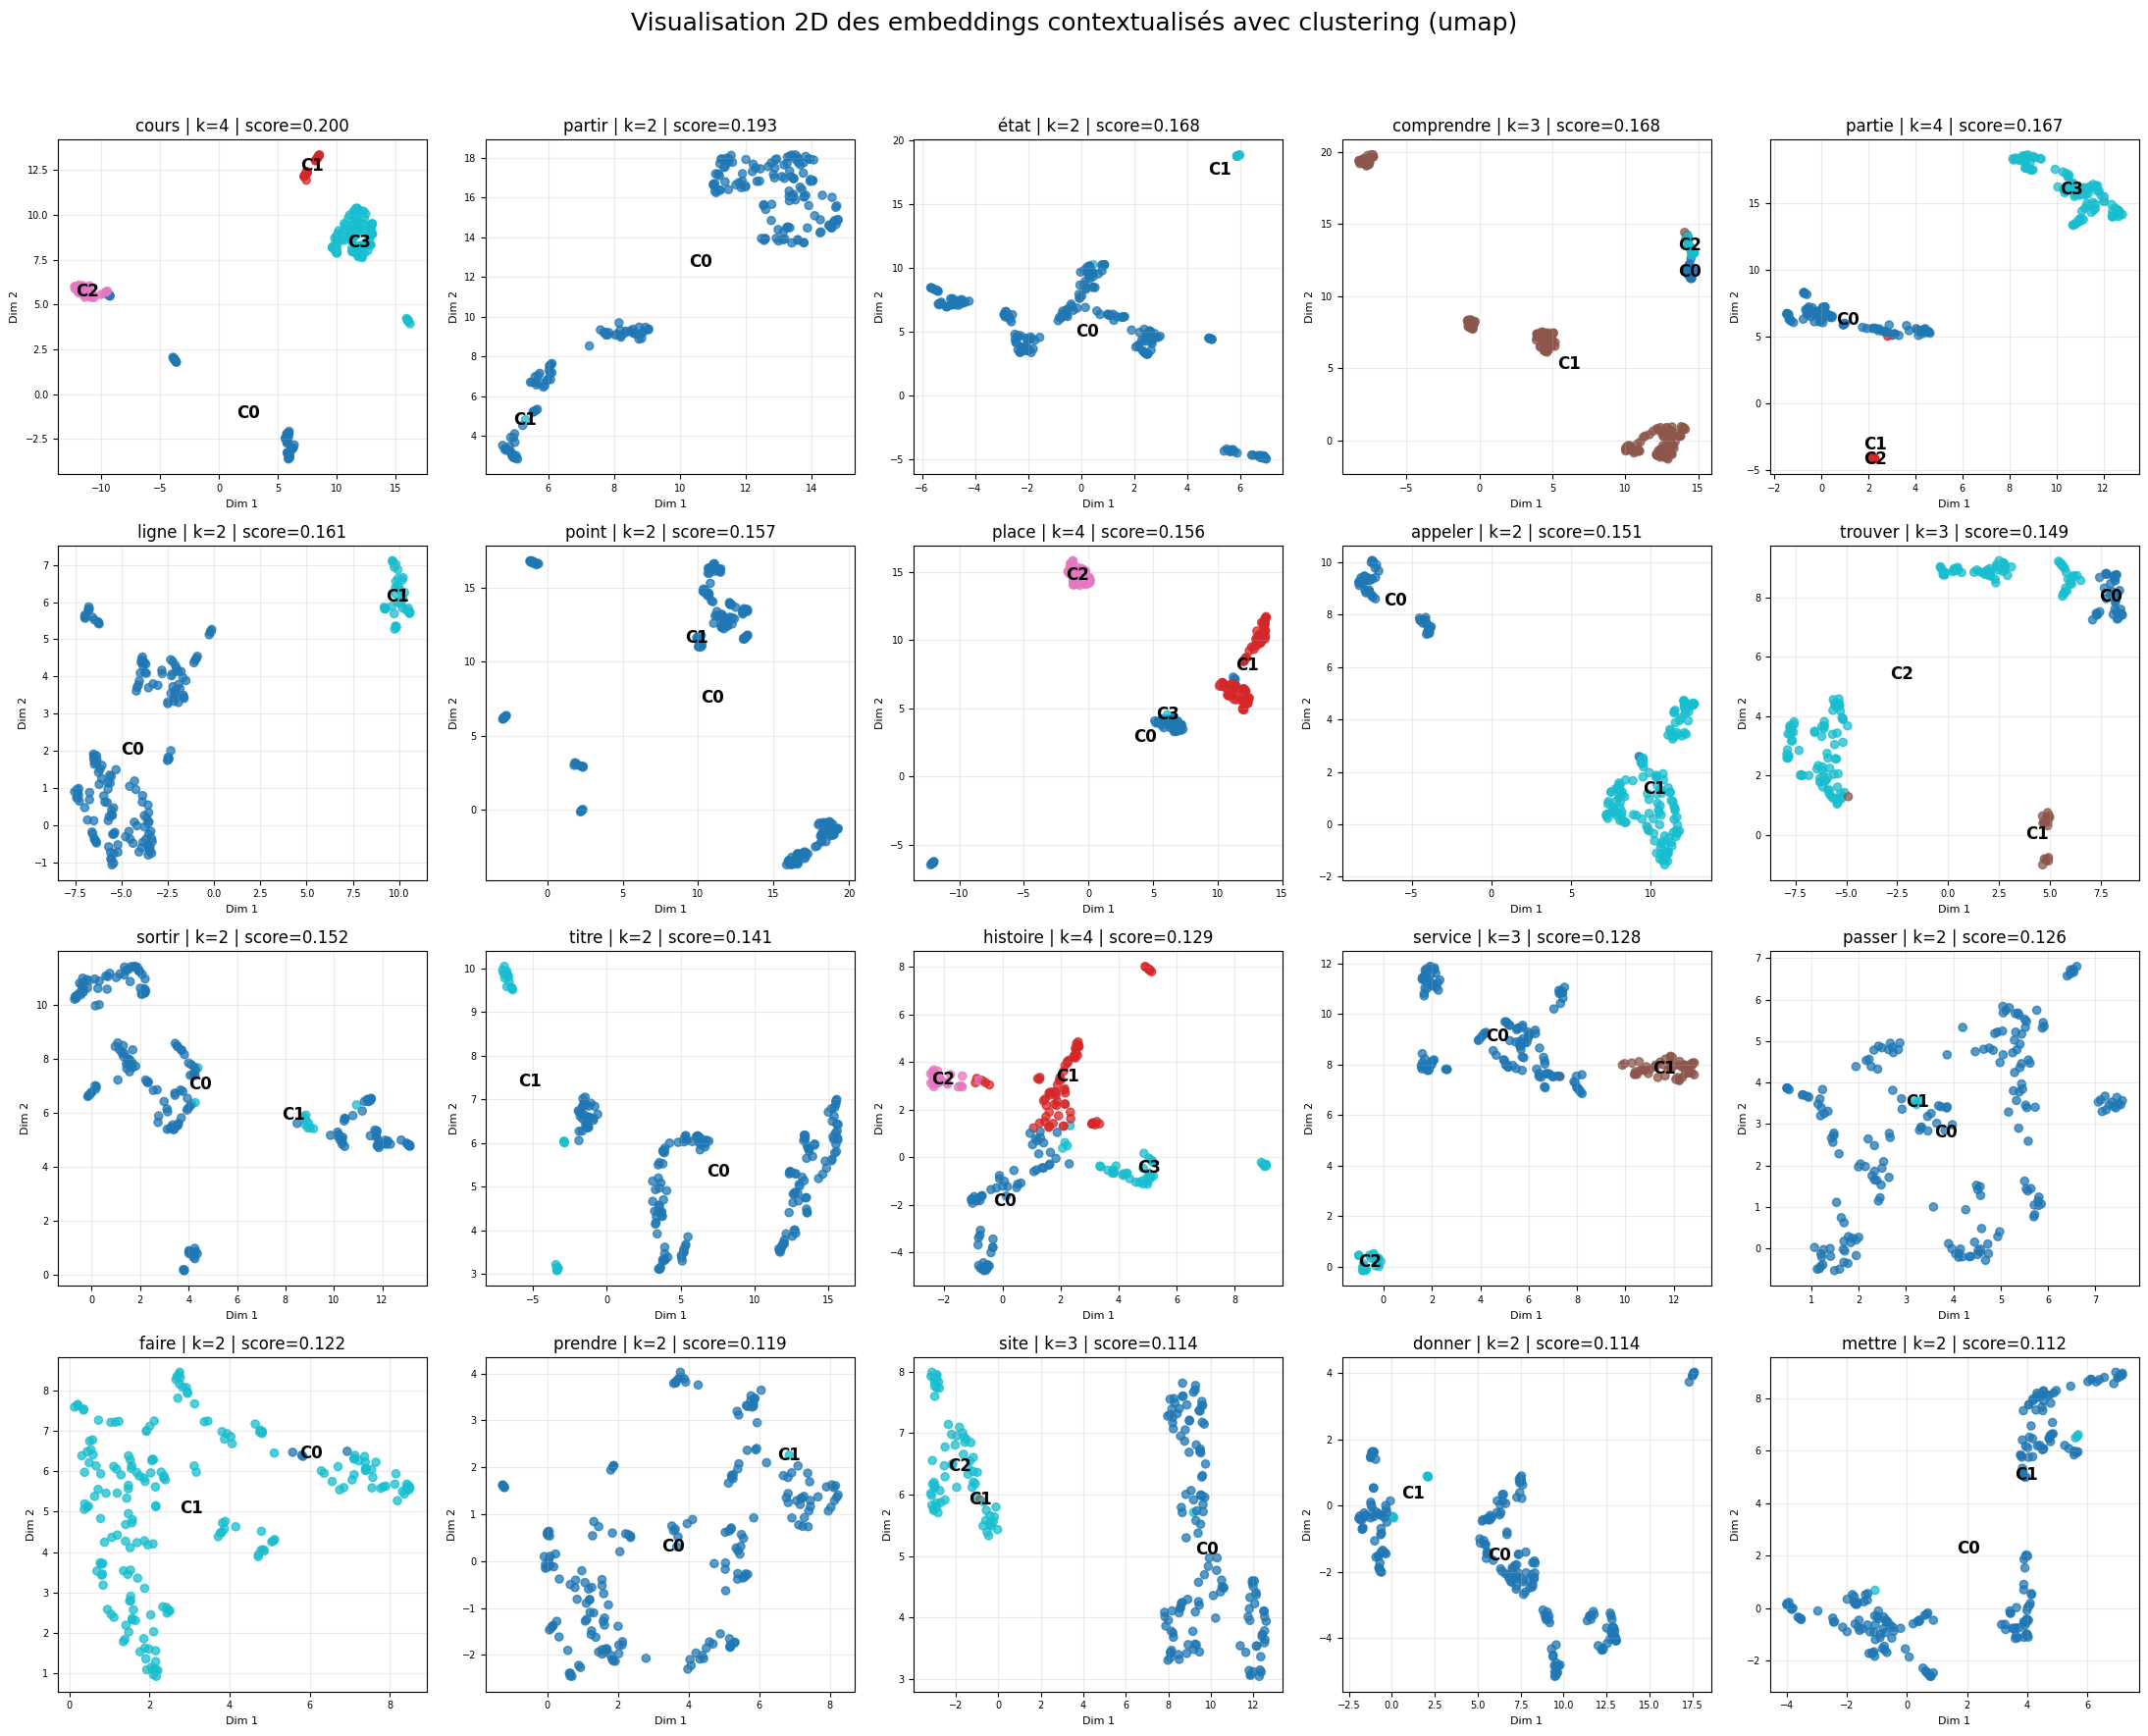

In [18]:
# =========================
# 9. Visualisation avec couleurs de clusters
# =========================
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"n_jobs value .* overridden to 1 by setting random_state.*",
    category=UserWarning,
    module=r"umap\.umap_"
)

methode = "umap" if UMAP_DISPONIBLE else "tsne"

mots_a_visualiser = (
    df_scores[df_scores["mot"].isin(mots_polysemies)]
    .sort_values("score_polysemie", ascending=False)
    ["mot"]
    .tolist()
)

n_cols = 5
n_rows = int(np.ceil(len(mots_a_visualiser) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
axes = np.array(axes).flatten()

resultats_clustering = {}

mots_a_visualiser = (
    df_scores[df_scores["mot"].isin(mots_a_visualiser)]
    .sort_values("score_polysemie", ascending=False)
    ["mot"]
    .tolist()
)

for i, mot in enumerate(mots_a_visualiser):
    ax = axes[i]
    X = embeddings_par_mot[mot]

    if len(X) < 5:
        ax.set_title(f"{mot}\nPas assez de points")
        ax.axis("off")
        continue

    # Choix automatique du nombre de clusters
    meilleur_k, scores_k = choisir_nombre_clusters(X, k_min=2, k_max=5)

    # Clustering dans l'espace original
    labels = clusteriser_embeddings(X, n_clusters=meilleur_k)

    # Réduction 2D seulement pour l'affichage
    coords = reduire_en_2d(X, methode=methode)

    resultats_clustering[mot] = {
        "k": meilleur_k,
        "labels": labels,
        "coords": coords,
        "scores_k": scores_k
    }

    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.75,
        s=35
    )

    # Afficher le numéro du cluster au centre de chaque groupe
    for cluster_id in sorted(set(labels)):
        indices = np.where(labels == cluster_id)[0]
        centre_2d = coords[indices].mean(axis=0)

        ax.text(
            centre_2d[0],
            centre_2d[1],
            f"C{cluster_id}",
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="center"
        )

    score = score_polysemie(X)

    ax.set_title(
        f"{mot} | k={meilleur_k} | score={score:.3f}",
        fontsize=12
    )

    ax.set_xlabel("Dim 1", fontsize=8)
    ax.set_ylabel("Dim 2", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(True, alpha=0.25)

for j in range(len(mots_a_visualiser), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"Visualisation 2D des embeddings contextualisés avec clustering ({methode})",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [19]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from IPython.display import display, HTML

def extraire_exemples_table(n_exemples=2):
    """
    输出格式：
    每一行 = 一个词语
    每一列 = C0, C1, C2...
    每个格子 = 该 cluster 的若干代表句子
    """

    lignes = []

    for mot in resultats_clustering.keys():
        X = embeddings_par_mot[mot]
        X_norm = normalize(X)

        labels = resultats_clustering[mot]["labels"]
        phrases = phrases_valides_par_mot[mot]

        ligne = {"mot": mot}

        for cluster_id in sorted(set(labels)):
            indices = np.where(labels == cluster_id)[0]

            X_cluster = X_norm[indices]

            # cluster 中心
            centroide = X_cluster.mean(axis=0, keepdims=True)
            centroide = normalize(centroide)

            # 找离中心最近的句子
            similarities = cosine_similarity(X_cluster, centroide).flatten()
            meilleurs_indices_locaux = np.argsort(similarities)[::-1][:n_exemples]
            meilleurs_indices_globaux = indices[meilleurs_indices_locaux]

            exemples = []
            for i, idx in enumerate(meilleurs_indices_globaux, start=1):
                exemples.append(f"{i}. {phrases[idx]}")

            ligne[f"C{cluster_id}"] = "<br>".join(exemples)

        lignes.append(ligne)

    df = pd.DataFrame(lignes)

    # 按照 C0, C1, C2... 排列列顺序
    colonnes_clusters = sorted(
        [col for col in df.columns if col.startswith("C")],
        key=lambda x: int(x[1:])
    )

    df = df[["mot"] + colonnes_clusters]

    return df

In [20]:
df_exemples = extraire_exemples_table(n_exemples=2)

# 把没有的 cluster 显示为空白
df_exemples = df_exemples.fillna("")

display(HTML(df_exemples.to_html(escape=False, index=False)))

mot,C0,C1,C2,C3
cours,"1. L'alluvion profite au propriétaire riverain, qu'il s'agisse d'un cours d'eau domanial ou non ;2. Les îles et atterrissements qui se forment dans les cours d'eau non domaniaux, appartiennent aux propriétaires riverains du côté où l'île s'est formée : si l'île n'est pas formée d'un seul côté, elle appartient aux propriétaires riverains des deux côtés, à partir de la ligne qu'on suppose tracée au milieu du cours d'eau. (Article 561)","1. Des preuves photographiques du squelette en cours de fouille sont également disponibles, montrant les ossements in situ, ainsi que la monture du musée squelettique.2. La partie DSP du framework est en cours d'écriture (en ) Le logiciel Geco de Hora Music comporte une interface de production graphique des modules.","1. Il a commencé des cours de théâtre avec l'entraîneur Diana Castle de La Vida Imaginaria, une académie de théâtre prestigieuse.2. Pendant ses années de lycée, il a reçu des cours de théâtre à Houston avec Deke Anderson.","1. Au cours des deux premières années du championnat du monde de Superbike, Honda a remporté la série avec son RC30, propulsé par un V4 de .2. Au cours de la dernière période glaciaire, la terre arable a été enlevée, laissant essentiellement des roches nues."
partir,"1. À partir de 1940, la RAF utilisa les Hector comme remorqueurs de cibles, ainsi que pour remorquer le planeur d’entraînement Hotspur.2. À partir de , le Hector équipa sept escadrons de coopération de l'armée de la RAF, mais commença à être remplacé par des Westland Lysander dès .","1. Durant les guerres civiles du règne de Charles VI, le château était l'une des places d'armes parti des Bourguignons.",,
état,"1. Le soutien populaire au parti, dans l'État espagnol, n'est jamais mis à l'épreuve.2. À Lecce, toutes les activités religieuses, sacramentelles et pastorales sont interdites jusqu'à ce que les graves tensions entre l'État et l'Église soient résolues en 1719.","1. Un premier bilan le lendemain fait état de douze morts et 188 blessés, compte qui monte à dix-sept morts (dont neuf à Port-de-Paix, sept à Gros-Morne et un à Saint-Louis-du-Nord) et 350 blessés2. Cette version a été contredite par la version officielle turque postérieure du , qui fait état d'une strangulation dès l'entrée dans le consulat, qui entraîne la mort, puis du démembrement de la victime une fois mise à nu.",,
comprendre,1. La superficie du lac Martin-Valin est comprise dans le territoire du parc national des Monts-Valin.2. Les lacs ont une superficie totale de pour une altitude comprise entre 2081 et 2175 m .,"1. La baie comprend le cours inférieur de la rivière Howard et plusieurs petits ruisseaux à marée qui se jettent dans Hope Inlet.2. Le système d’enseignement supérieur comprend 22 universités d’État, 37 universités privées, quatre universités régies par des accords intergouvernementaux et neuf antennes d’universités étrangères.","1. En effet, pour mieux comprendre l’oppression globale des femmes, le journal mise sur un espace de discussion où chacune des contributrices est invitée à partager les enjeux qui la préoccupent.2. Les recherches furent exécutées sur 2 zones différentes du site et les fouilles portèrent sur 4 endroits définis en fonction des caractéristiques visibles en surface, afin de découvrir et mieux comprendre les vestiges archéologiques sous terre.",
partie,"1. Une grande partie de la baie est exposée à marée basse, avec environ 100 km de vasières et de vasières de marée.2. La majeure partie du quartier forme le centre-ville actuel, la zone piétonne aménagée en 1967.","1. Il convient, tout au long de la partie, de faire des choix sur les combats à mener et d’évaluer au mieux forces et desseins des adversaires en lice.2. Fin de la partie (The Losers #23-32, 2011)","1. Une fois fixé sur le choix du navire, il élimine les contextes déjà abordés dans les jeux vidéo contemporains : pirates et autres galions ne seront pas de la partie, au contraire du début du et des navires marchands d

In [ ]:
# 备用

nb_sens_dictionnaire = {
    "cours": 8,
    "partir": 8,
    "état": 8,
    "comprendre": 5,
    "partie": 7,
    "ligne": 11,
    "point": 12,
    "place": 10,
    "appeler": 7,
    "trouver": 9,
    "site": 6,
    "titre": 9,
    "service": 12,
    "histoire": 9,
    "faire": 23,
    "prendre": 24,
    "sortir": 13,
    "passer": 16,
    "donner": 15,
    "mettre": 12
} # Le Grand Robert

## Imports pour Wiktionnaire

In [64]:
# =========================
# Bloc 1 — Imports pour Wiktionnaire et visualisation
# =========================

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
import math

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [65]:
# =========================
# Bloc 1bis — Import UMAP
# =========================

try:
    from umap import UMAP
    UMAP_DISPONIBLE = True
except ImportError:
    UMAP_DISPONIBLE = False
    print("UMAP non disponible : on utilisera PCA ou t-SNE.")

In [66]:
# =========================
# Bloc 2 — Nettoyage du texte
# =========================

def nettoyer_texte_wikt(texte):
    if texte is None:
        return ""
    
    texte = texte.replace("\xa0", " ")
    texte = re.sub(r"\s+", " ", texte)
    return texte.strip()

In [67]:
# =========================
# Bloc 3 — Paramètres API Wiktionnaire
# =========================

API_WIKTIONNAIRE = "https://fr.wiktionary.org/w/api.php"

HEADERS_WIKTIONNAIRE = {
    "User-Agent": "ProjetPolysemieBERT/0.1 (travail universitaire; contact: ton.email@example.com)",
    "Accept": "application/json"
}

In [68]:
# =========================
# Bloc 4 — Obtenir les sections d’une page Wiktionnaire
# =========================

def obtenir_sections_wiktionnaire(mot):
    params = {
        "action": "parse",
        "page": mot,
        "prop": "sections",
        "format": "json",
        "redirects": 1
    }
    
    response = requests.get(
        API_WIKTIONNAIRE,
        params=params,
        headers=HEADERS_WIKTIONNAIRE,
        timeout=20
    )
    response.raise_for_status()
    
    data = response.json()
    
    if "parse" not in data:
        return []
    
    return data["parse"]["sections"]

In [69]:
# =========================
# Bloc 5 — Télécharger la section française
# =========================

def trouver_index_section_francaise(mot):
    sections = obtenir_sections_wiktionnaire(mot)
    
    for sec in sections:
        if sec.get("line") == "Français" or sec.get("anchor") == "Français":
            return sec.get("index")
    
    return None


def telecharger_section_francaise_wiktionnaire(mot):
    index_fr = trouver_index_section_francaise(mot)
    
    if index_fr is None:
        return None
    
    params = {
        "action": "parse",
        "page": mot,
        "section": index_fr,
        "prop": "text",
        "format": "json",
        "redirects": 1
    }
    
    response = requests.get(
        API_WIKTIONNAIRE,
        params=params,
        headers=HEADERS_WIKTIONNAIRE,
        timeout=20
    )
    response.raise_for_status()
    
    data = response.json()
    
    if "parse" not in data:
        return None
    
    return data["parse"]["text"]["*"]

In [71]:
# =========================
# Bloc 6 — Extraire les sens et les exemples Wiktionnaire
# =========================

CATEGORIES_POS_PRINCIPALES = [
    "Nom commun",
    "Nom propre",
    "Verbe",
    "Adjectif",
    "Adverbe"
]

def est_pos_principale(titre):
    return any(titre.startswith(cat) for cat in CATEGORIES_POS_PRINCIPALES)


def extraire_sens_wiktionnaire(mot, max_exemples_par_sens=3):
    html_fr = telecharger_section_francaise_wiktionnaire(mot)
    
    if html_fr is None:
        return []
    
    soup_fr = BeautifulSoup(html_fr, "html.parser")
    
    resultats = []
    pos_actuelle = None
    extraction_active = False
    compteur_sens = 0
    
    elements = soup_fr.find_all(["h3", "h4", "ol"])
    
    for elem in elements:
        if elem.name in ["h3", "h4"]:
            titre = nettoyer_texte_wikt(elem.get_text(" ", strip=True))
            
            if est_pos_principale(titre):
                pos_actuelle = titre
                extraction_active = True
            else:
                pos_actuelle = None
                extraction_active = False
            
            continue
        
        if elem.name == "ol" and extraction_active and pos_actuelle is not None:
            lis = elem.find_all("li", recursive=False)
            
            for li in lis:
                exemples = []
                
                for sous_liste in li.find_all(["ul", "ol"]):
                    for ex_li in sous_liste.find_all("li", recursive=False):
                        exemple = nettoyer_texte_wikt(ex_li.get_text(" ", strip=True))
                        if exemple:
                            exemples.append(exemple)
                
                exemples = exemples[:max_exemples_par_sens]
                
                li_copy = BeautifulSoup(str(li), "html.parser")
                for sous_liste in li_copy.find_all(["ul", "ol"]):
                    sous_liste.decompose()
                
                definition = nettoyer_texte_wikt(li_copy.get_text(" ", strip=True))
                
                if definition:
                    compteur_sens += 1
                    resultats.append({
                        "mot": mot,
                        "pos": pos_actuelle,
                        "sens_id": f"S{compteur_sens}",
                        "definition": definition,
                        "exemples": exemples
                    })
    
    return resultats

In [72]:
# =========================
# Bloc 7 — Extraire les sens Wiktionnaire pour les mots cibles
# =========================

mots_cibles = list(resultats_clustering.keys())

tous_sens_wiktionnaire = []

for mot in mots_cibles:
    print("Extraction Wiktionnaire :", mot)
    
    try:
        sens_mot = extraire_sens_wiktionnaire(
            mot,
            max_exemples_par_sens=3
        )
        print("  Nombre de sens extraits :", len(sens_mot))
        tous_sens_wiktionnaire.extend(sens_mot)
        
    except Exception as e:
        print("  Erreur pour", mot, ":", e)
    
    time.sleep(0.5)

df_wiktionnaire = pd.DataFrame(tous_sens_wiktionnaire)

print("Nombre total de lignes :", len(df_wiktionnaire))
display(df_wiktionnaire.head())

Extraction Wiktionnaire : cours
  Nombre de sens extraits : 26
Extraction Wiktionnaire : partir
  Nombre de sens extraits : 13
Extraction Wiktionnaire : état
  Nombre de sens extraits : 8
Extraction Wiktionnaire : comprendre
  Nombre de sens extraits : 9
Extraction Wiktionnaire : partie
  Nombre de sens extraits : 12
Extraction Wiktionnaire : ligne
  Nombre de sens extraits : 34
Extraction Wiktionnaire : point
  Nombre de sens extraits : 37
Extraction Wiktionnaire : place
  Nombre de sens extraits : 11
Extraction Wiktionnaire : appeler
  Nombre de sens extraits : 23
Extraction Wiktionnaire : trouver
  Nombre de sens extraits : 10
Extraction Wiktionnaire : sortir
  Nombre de sens extraits : 22
Extraction Wiktionnaire : titre
  Nombre de sens extraits : 15
Extraction Wiktionnaire : histoire
  Nombre de sens extraits : 13
Extraction Wiktionnaire : service
  Nombre de sens extraits : 21
Extraction Wiktionnaire : passer
  Nombre de sens extraits : 50
Extraction Wiktionnaire : faire
  Nombre

,mot,pos,sens_id,definition,exemples
0,cours,Nom commun,S1,Mouvement d’ écoulement naturel dans l’ espace...,"[VERON, petite rivière ou ruisseau de Berri, d..."
1,cours,Nom commun,S2,"( Hydrologie ) Flux , étendue parcourue par l’...",[La route parcourt une campagne fertile et var...
2,cours,Nom commun,S3,( Biologie ) Circulation d’un liquide canalisé...,[C’est en modifiant le calibre des vaisseaux e...
3,cours,Nom commun,S4,"( Astronomie ) Mouvement , course réel ou appa...","[Que puisses-tu, grand soleil de nos jours, Fa..."
4,cours,Nom commun,S5,( Par analogie ) Étendue de certaines choses c...,[[…] principalement l’idée qu’il avoit d’établ...


In [73]:
# =========================
# Bloc 8 — Construire le corpus d’exemples Wiktionnaire
# =========================

lignes_corpus_wikt = []

for _, row in df_wiktionnaire.iterrows():
    mot = row["mot"]
    pos = row["pos"]
    sens_id = row["sens_id"]
    definition = row["definition"]
    exemples = row["exemples"]
    
    if not isinstance(exemples, list):
        continue
    
    for exemple in exemples:
        if isinstance(exemple, str) and len(exemple.strip()) > 0:
            lignes_corpus_wikt.append({
                "mot": mot,
                "pos": pos,
                "sens_id": sens_id,
                "definition": definition,
                "phrase": exemple
            })

df_corpus_wiktionnaire = pd.DataFrame(lignes_corpus_wikt)

print("Nombre total d'exemples Wiktionnaire :", len(df_corpus_wiktionnaire))
display(df_corpus_wiktionnaire.head())

Nombre total d'exemples Wiktionnaire : 1000


,mot,pos,sens_id,definition,phrase
0,cours,Nom commun,S1,Mouvement d’ écoulement naturel dans l’ espace...,"VERON, petite rivière ou ruisseau de Berri, de..."
1,cours,Nom commun,S2,"( Hydrologie ) Flux , étendue parcourue par l’...",La route parcourt une campagne fertile et vari...
2,cours,Nom commun,S2,"( Hydrologie ) Flux , étendue parcourue par l’...","Dans cette partie de son cours , la Lanterne r..."
3,cours,Nom commun,S2,"( Hydrologie ) Flux , étendue parcourue par l’...",La colonne descend dans la vallée au Sud du ca...
4,cours,Nom commun,S3,( Biologie ) Circulation d’un liquide canalisé...,C’est en modifiant le calibre des vaisseaux et...


In [74]:
# =========================
# Bloc 9 — Calculer les embeddings CamemBERT des exemples Wiktionnaire
# =========================

embeddings_wiktionnaire = []
lignes_valides_wiktionnaire = []

for _, row in tqdm(
    df_corpus_wiktionnaire.iterrows(),
    total=len(df_corpus_wiktionnaire),
    desc="Embeddings Wiktionnaire"
):
    mot = row["mot"]
    phrase = row["phrase"]
    
    vec, forme_trouvee = get_embedding_mot_dans_phrase_par_lemme(phrase, mot)
    
    if vec is not None:
        ligne = row.to_dict()
        ligne["forme_trouvee"] = forme_trouvee
        
        embeddings_wiktionnaire.append(vec)
        lignes_valides_wiktionnaire.append(ligne)

embeddings_wiktionnaire = np.array(embeddings_wiktionnaire)
df_corpus_wiktionnaire_valide = pd.DataFrame(lignes_valides_wiktionnaire).reset_index(drop=True)

print("Nombre d'exemples avant filtrage :", len(df_corpus_wiktionnaire))
print("Nombre d'exemples valides :", len(df_corpus_wiktionnaire_valide))
print("Shape embeddings :", embeddings_wiktionnaire.shape)

display(df_corpus_wiktionnaire_valide.head())

Embeddings Wiktionnaire: 100%|██████████| 1000/1000 [00:37<00:00, 26.35it/s]


Nombre d'exemples avant filtrage : 1000
Nombre d'exemples valides : 924
Shape embeddings : (924, 768)


,mot,pos,sens_id,definition,phrase,forme_trouvee
0,cours,Nom commun,S1,Mouvement d’ écoulement naturel dans l’ espace...,"VERON, petite rivière ou ruisseau de Berri, de...",cours
1,cours,Nom commun,S2,"( Hydrologie ) Flux , étendue parcourue par l’...",La route parcourt une campagne fertile et vari...,cours
2,cours,Nom commun,S2,"( Hydrologie ) Flux , étendue parcourue par l’...","Dans cette partie de son cours , la Lanterne r...",cours
3,cours,Nom commun,S2,"( Hydrologie ) Flux , étendue parcourue par l’...",La colonne descend dans la vallée au Sud du ca...,cours
4,cours,Nom commun,S3,( Biologie ) Circulation d’un liquide canalisé...,C’est en modifiant le calibre des vaisseaux et...,cours


In [75]:
# =========================
# Bloc 10 — Vérifier le nombre d’exemples valides par mot
# =========================

df_nb_exemples_wikt_valides = (
    df_corpus_wiktionnaire_valide
    .groupby("mot")
    .agg(
        nb_exemples_valides=("phrase", "count"),
        nb_sens_valides=("sens_id", "nunique")
    )
    .reset_index()
    .sort_values("nb_exemples_valides", ascending=False)
)

display(df_nb_exemples_wikt_valides)

,mot,nb_exemples_valides,nb_sens_valides
4,faire,157,62
13,prendre,124,67
10,passer,96,47
3,donner,78,51
12,point,54,28
6,ligne,47,28
2,cours,46,25
0,appeler,42,23
16,sortir,40,22
7,mettre,38,20


In [76]:
# =========================
# Bloc 11 — Réduction en 2D
# =========================

def reduire_wiktionnaire_en_2d(X, methode="umap"):
    X_norm = normalize(X)
    n = len(X_norm)
    
    if n < 2:
        raise ValueError("Il faut au moins 2 exemples.")
    
    if methode == "pca":
        reducer = PCA(n_components=2, random_state=42)
        return reducer.fit_transform(X_norm)
    
    elif methode == "umap":
        if (not UMAP_DISPONIBLE) or n < 5:
            reducer = PCA(n_components=2, random_state=42)
            return reducer.fit_transform(X_norm)
        
        n_neighbors = min(10, n - 1)
        
        reducer = UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=0.05,
            metric="cosine",
            random_state=42
        )
        return reducer.fit_transform(X_norm)
    
    elif methode == "tsne":
        if n < 5:
            reducer = PCA(n_components=2, random_state=42)
            return reducer.fit_transform(X_norm)
        
        perplexity = min(30, max(2, (n - 1) // 3))
        
        reducer = TSNE(
            n_components=2,
            perplexity=perplexity,
            metric="cosine",
            init="pca",
            learning_rate="auto",
            random_state=42
        )
        return reducer.fit_transform(X_norm)
    
    else:
        raise ValueError("methode doit être 'umap', 'pca' ou 'tsne'")

In [83]:
# =========================
# Bloc 12 — Clustering Wiktionnaire avec AgglomerativeClustering
# =========================

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

def clusteriser_exemples_wiktionnaire_mot(
    mot,
    k=None,
    k_min=2,
    k_max=8
):
    """
    Clusterise les exemples Wiktionnaire d'un mot avec :
    - normalisation des embeddings
    - AgglomerativeClustering
    - distance cosinus
    - linkage average

    Si k=None, le meilleur k est choisi par silhouette.
    """
    
    df_mot = df_corpus_wiktionnaire_valide[
        df_corpus_wiktionnaire_valide["mot"] == mot
    ].copy()
    
    if len(df_mot) < 4:
        raise ValueError(f"Pas assez d'exemples valides pour clusteriser : {mot}")
    
    idx_global = df_mot.index.to_numpy()
    X = embeddings_wiktionnaire[idx_global]
    X_norm = normalize(X)
    
    n = len(X_norm)
    scores_silhouette = {}
    
    def agglomerative_labels(X_norm, n_clusters):
        try:
            clustering = AgglomerativeClustering(
                n_clusters=n_clusters,
                metric="cosine",
                linkage="average"
            )
        except TypeError:
            clustering = AgglomerativeClustering(
                n_clusters=n_clusters,
                affinity="cosine",
                linkage="average"
            )
        
        return clustering.fit_predict(X_norm)
    
    if k is None:
        k_max_effectif = min(k_max, n - 1)
        
        meilleur_score = -1
        meilleur_k = None
        meilleurs_labels = None
        
        for k_test in range(k_min, k_max_effectif + 1):
            try:
                labels_test = agglomerative_labels(X_norm, k_test)
                
                if len(set(labels_test)) < 2:
                    continue
                
                score = silhouette_score(
                    X_norm,
                    labels_test,
                    metric="cosine"
                )
                
                scores_silhouette[k_test] = score
                
                if score > meilleur_score:
                    meilleur_score = score
                    meilleur_k = k_test
                    meilleurs_labels = labels_test
            
            except Exception:
                continue
        
        if meilleurs_labels is None:
            meilleur_k = 2
            meilleurs_labels = agglomerative_labels(X_norm, 2)
            meilleur_score = silhouette_score(
                X_norm,
                meilleurs_labels,
                metric="cosine"
            )
        
        labels = meilleurs_labels
        k_final = meilleur_k
        score_final = meilleur_score
    
    else:
        labels = agglomerative_labels(X_norm, k)
        k_final = k
        
        if len(set(labels)) > 1:
            score_final = silhouette_score(
                X_norm,
                labels,
                metric="cosine"
            )
        else:
            score_final = np.nan
    
    df_mot = df_mot.reset_index(drop=True)
    df_mot["cluster"] = labels
    df_mot["cluster_label"] = [f"C{c}" for c in labels]
    
    return df_mot, X, labels, k_final, score_final, scores_silhouette

In [84]:
# =========================
# Bloc 13 — Visualisation d’un seul mot avec clustering hiérarchique
# =========================

def visualiser_clustering_wiktionnaire_mot(
    mot,
    k=None,
    methode="umap",
    k_min=2,
    k_max=8,
    figsize=(6, 5)
):
    df_mot, X, labels, k_final, score_final, _ = clusteriser_exemples_wiktionnaire_mot(
        mot=mot,
        k=k,
        k_min=k_min,
        k_max=k_max
    )
    
    coords = reduire_wiktionnaire_en_2d(X, methode=methode)
    df_mot["x"] = coords[:, 0]
    df_mot["y"] = coords[:, 1]
    
    plt.figure(figsize=figsize)
    
    clusters_uniques = sorted(df_mot["cluster"].unique())
    
    for c in clusters_uniques:
        sous_df = df_mot[df_mot["cluster"] == c]
        
        plt.scatter(
            sous_df["x"],
            sous_df["y"],
            label=f"C{c}",
            alpha=0.85,
            s=35
        )
        
        centre_x = sous_df["x"].mean()
        centre_y = sous_df["y"].mean()
        
        plt.text(
            centre_x,
            centre_y,
            f"C{c}",
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="center"
        )
    
    titre_score = "nan" if pd.isna(score_final) else f"{score_final:.3f}"
    
    plt.title(f"{mot} | k={k_final} | score={titre_score}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df_mot

In [88]:
# =========================
# Bloc 14bis — Visualisation en grille triée par score décroissant
# =========================

def visualiser_grille_clustering_wiktionnaire(
    mots,
    k_par_mot=None,
    methode="umap",
    k_min=2,
    k_max=8,
    ncols=5,
    figsize_par_subplot=(3.8, 3.2),
    trier_par_score=True
):
    """
    Batch visualisation.
    
    Chaque subplot = un mot.
    Clustering = AgglomerativeClustering + distance cosinus.
    
    Si trier_par_score=True :
    les mots sont affichés du score silhouette le plus élevé au plus faible.
    """
    
    resultats = []
    
    for mot in mots:
        try:
            k_mot = None
            if k_par_mot is not None and mot in k_par_mot:
                k_mot = k_par_mot[mot]
            
            df_mot, X, labels, k_final, score_final, scores_sil = clusteriser_exemples_wiktionnaire_mot(
                mot=mot,
                k=k_mot,
                k_min=k_min,
                k_max=k_max
            )
            
            coords = reduire_wiktionnaire_en_2d(X, methode=methode)
            df_mot["x"] = coords[:, 0]
            df_mot["y"] = coords[:, 1]
            
            resultats.append({
                "mot": mot,
                "df": df_mot,
                "k_final": k_final,
                "score_final": score_final,
                "scores_silhouette": scores_sil
            })
        
        except Exception as e:
            print(f"Erreur pour {mot} : {e}")
    
    if len(resultats) == 0:
        print("Aucun mot à afficher.")
        return []
    
    # Trier les mots selon le score silhouette décroissant
    if trier_par_score:
        resultats = sorted(
            resultats,
            key=lambda x: -np.inf if pd.isna(x["score_final"]) else x["score_final"],
            reverse=True
        )
    
    n = len(resultats)
    nrows = math.ceil(n / ncols)
    
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_par_subplot[0] * ncols, figsize_par_subplot[1] * nrows)
    )
    
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])
    
    axes_flat = axes.flatten()
    
    for ax_idx, ax in enumerate(axes_flat):
        if ax_idx >= len(resultats):
            ax.axis("off")
            continue
        
        item = resultats[ax_idx]
        mot = item["mot"]
        df_mot = item["df"]
        k_final = item["k_final"]
        score_final = item["score_final"]
        
        clusters_uniques = sorted(df_mot["cluster"].unique())
        
        for c in clusters_uniques:
            sous_df = df_mot[df_mot["cluster"] == c]
            
            ax.scatter(
                sous_df["x"],
                sous_df["y"],
                alpha=0.85,
                s=16,
                label=f"C{c}"
            )
            
            centre_x = sous_df["x"].mean()
            centre_y = sous_df["y"].mean()
            
            ax.text(
                centre_x,
                centre_y,
                f"C{c}",
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center"
            )
        
        titre_score = "nan" if pd.isna(score_final) else f"{score_final:.3f}"
        
        ax.set_title(f"{mot} | k={k_final} | score={titre_score}", fontsize=10)
        ax.set_xlabel("Dim 1", fontsize=8)
        ax.set_ylabel("Dim 2", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="both", labelsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return resultats

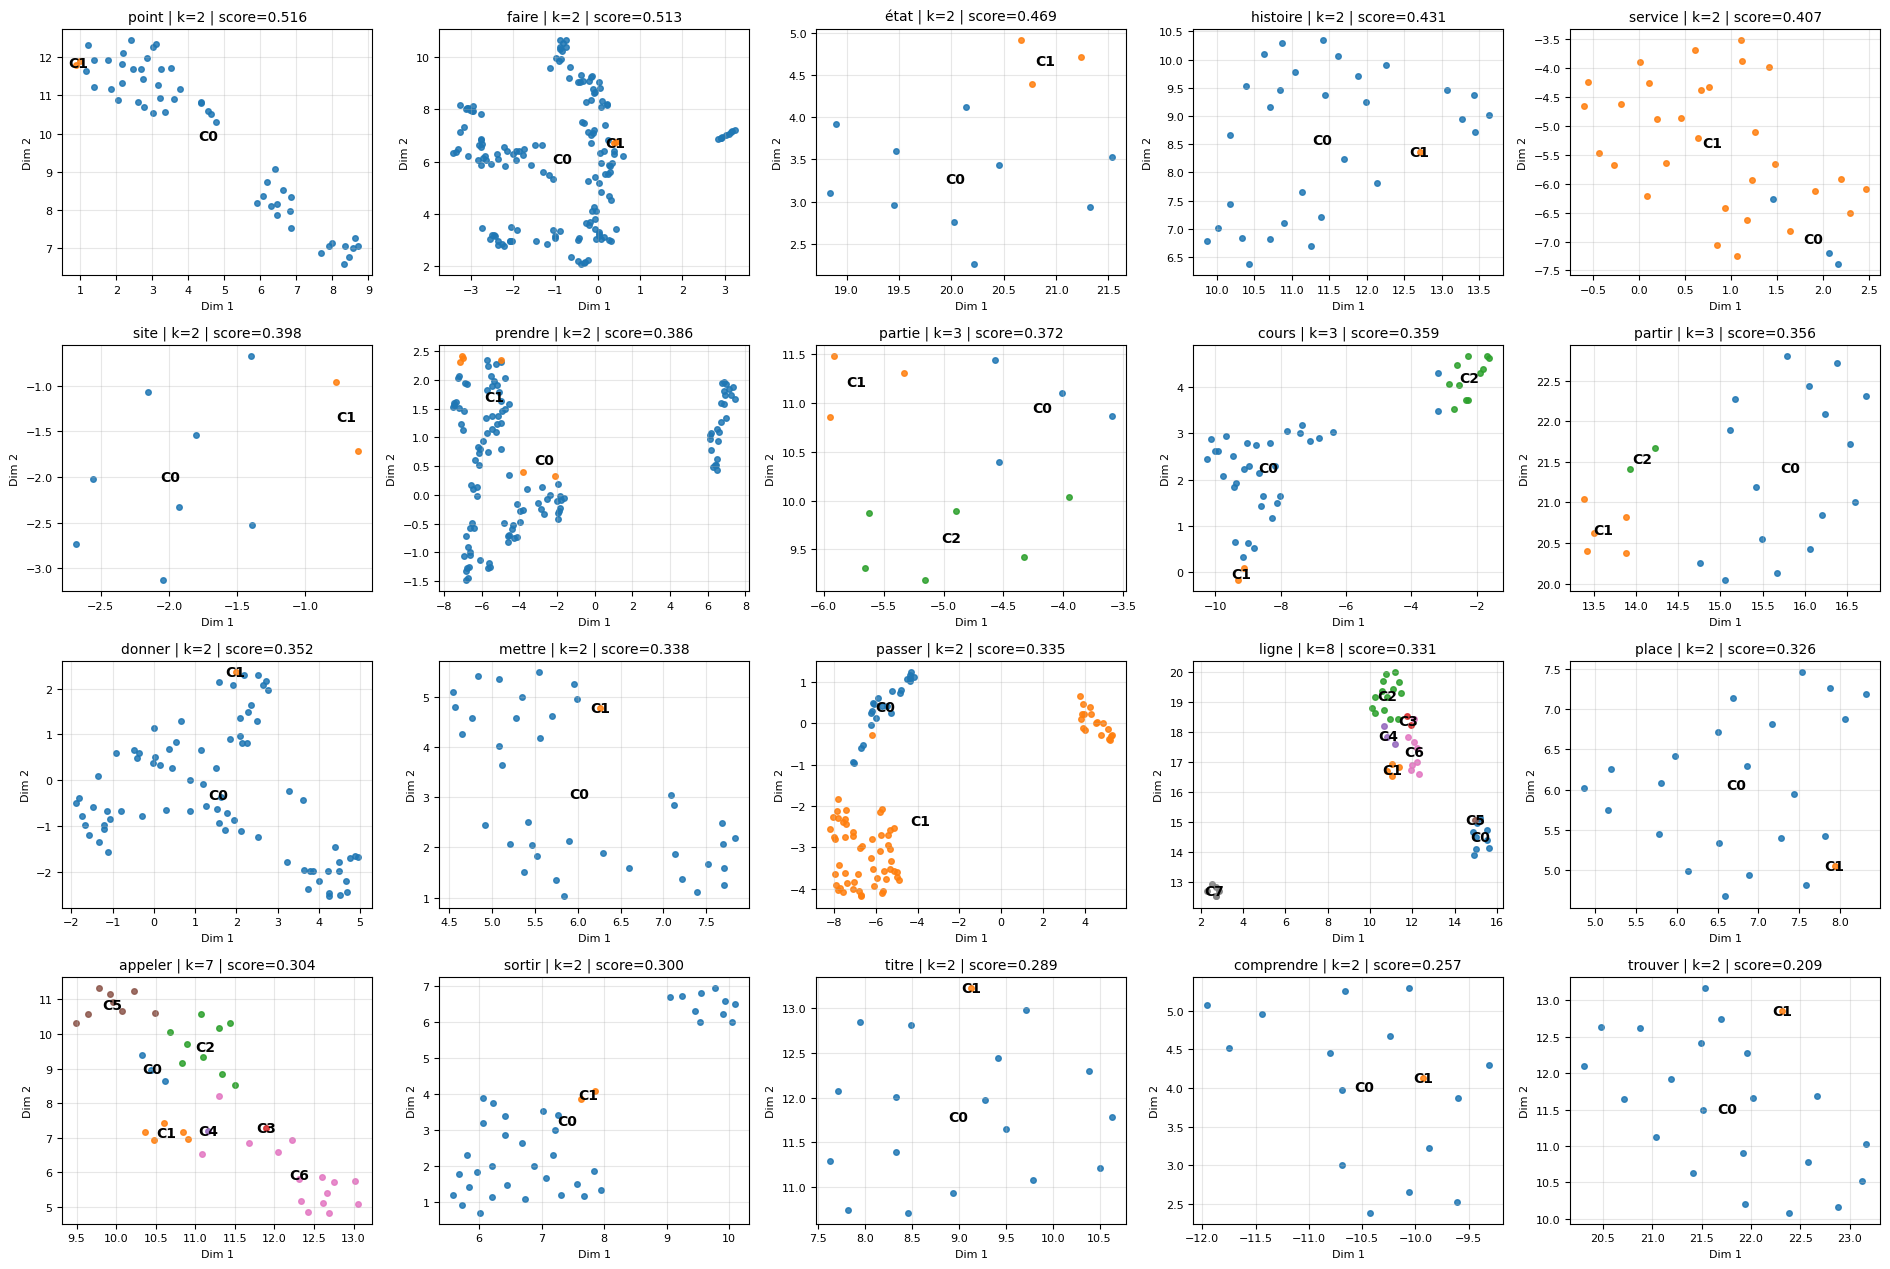

In [89]:
# =========================
# Bloc 15 — Lancer la grille Wiktionnaire avec clustering hiérarchique
# =========================

resultats_grille_wiktionnaire = visualiser_grille_clustering_wiktionnaire(
    mots=mots_polysemies,
    k_par_mot=None,
    methode="umap",
    k_min=2,
    k_max=8,
    ncols=5
)

In [90]:
# =========================
# Bloc final — Tableau d’exemples Wiktionnaire par mot et par cluster
# =========================

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from IPython.display import display, HTML
import pandas as pd
import numpy as np

def construire_table_exemples_wiktionnaire(
    mots,
    n_exemples=2,
    k_par_mot=None,
    k_min=2,
    k_max=8
):
    """
    Construit un tableau :
    - une ligne par mot
    - une colonne par cluster C0, C1, C2...
    - chaque cellule contient n exemples représentatifs du cluster
    
    Les exemples représentatifs sont ceux qui sont les plus proches
    du centroïde du cluster.
    """
    
    lignes = []
    
    for mot in mots:
        try:
            k_mot = None
            if k_par_mot is not None and mot in k_par_mot:
                k_mot = k_par_mot[mot]
            
            df_mot, X, labels, k_final, score_final, scores_sil = clusteriser_exemples_wiktionnaire_mot(
                mot=mot,
                k=k_mot,
                k_min=k_min,
                k_max=k_max
            )
            
            X_norm = normalize(X)
            ligne = {"mot": mot}
            
            clusters = sorted(set(labels))
            
            for cluster_id in clusters:
                indices_cluster = np.where(labels == cluster_id)[0]
                X_cluster = X_norm[indices_cluster]
                
                # Centroïde du cluster
                centroide = X_cluster.mean(axis=0, keepdims=True)
                centroide = normalize(centroide)
                
                # Similarité au centroïde
                similarities = cosine_similarity(X_cluster, centroide).flatten()
                
                # Exemples les plus proches du centroïde
                meilleurs_indices_locaux = np.argsort(similarities)[::-1][:n_exemples]
                meilleurs_indices_globaux = indices_cluster[meilleurs_indices_locaux]
                
                exemples = []
                
                for rang, idx in enumerate(meilleurs_indices_globaux, start=1):
                    phrase = df_mot.iloc[idx]["phrase"]
                    exemples.append(f"{rang}. {phrase}")
                
                ligne[f"C{cluster_id}"] = "<br><br>".join(exemples)
            
            lignes.append(ligne)
        
        except Exception as e:
            print(f"Erreur pour {mot} : {e}")
    
    df_table = pd.DataFrame(lignes)
    
    # Ordonner les colonnes C0, C1, C2...
    colonnes_clusters = sorted(
        [col for col in df_table.columns if col.startswith("C")],
        key=lambda x: int(x[1:])
    )
    
    df_table = df_table[["mot"] + colonnes_clusters]
    df_table = df_table.fillna("")
    
    return df_table


# Construire le tableau pour tous les mots
df_exemples_wiktionnaire = construire_table_exemples_wiktionnaire(
    mots=mots_polysemies,
    n_exemples=2,
    k_par_mot=None,
    k_min=2,
    k_max=8
)

# Afficher le tableau dans le notebook
display(
    HTML(
        df_exemples_wiktionnaire.to_html(
            escape=False,
            index=False
        )
    )
)

mot,C0,C1,C2,C3,C4,C5,C6,C7
site,"1. Quel paysage ! ruminait Durtal, […]. Il se rappelait l’effroi du site qu’il avait traversé entre Saint-Georges de Commiers et La Mure, son effarement en wagon lorsque le train passait lentement au-dessus des gouffres. — ( Joris-Karl Huysmans , La Cathédrale , Plon-Nourrit, 1915)2. Bordeaux est donc un emporium maritime. Mais c’est aussi un lieu de passage. Le site qu’il occupe est le dernier point de terre ferme qui s’offre en descendant la rive gauche du fleuve. Plus bas l’énorme élargissement de l’estuaire, les marais qui le bordent, forment barrière. — (Vidal de La Blache, Tableau géographique français , 1908, page 373)","1. De nombreuses informations disponibles sur Internet ne sont pas sourcées. C'est ainsi que des informations fausses peuvent être dupliquées d'un site à l'autre, ce qui leur procure une forme de légitimité. — (Emmanuel Kessous, L'attention au monde: Sociologie des données personnelles à l'ère numérique , Armand Colin, 2012)2. Les sources d’information appuyant la version alternative se trouvent surtout sur Internet. La validité des faits et des arguments rapportés dans de nombreux sites Web « amateurs » se révèle souvent douteuse ou carrément nulle. — (Louis Dubé, L’argument déterminant et les théories du complot , dans Le Québec sceptique , n o 67, p.5, automne 2008)",,,,,,
partie,"1. Quelquefois il me disait de me promener devant lui avec Pierrette, et il nous faisait chanter ensemble, nous apprenant à chanter en partie . — ( Alfred de Vigny , Servitude et grandeur militaires , 1835)2. Nous étions allés en partie à la maison de campagne de la señora ***. — ( Théophile Gautier , Voyage en Espagne , 1840, édition Charpentier, 1859)","1. Avant d'être envoyé au moulin, le blé est préalablement soumis chez les cultivateurs à un vannage qui en sépare une partie des corps les plus légers. — ( Edmond Nivoit , Notions élémentaires sur l’industrie dans le département des Ardennes , E. Jolly, Charleville, 1869, page 107)2. Pour enlever une grande partie de ces traces utilisez une bombe nettoyante.","1. Il fit rapidement ses préparatifs, ramassa un aviron qu’il avait caché d’avance dans le fond, le fit glisser à l’arrière et se mit à « godailler » tout en continuant ses explications d’un ton joyeux, et comme s’il ne s’était rien passé de plus extraordinaire que ce qui se passe au cours d’une partie de plaisir. — ( Maurice Leblanc , La Comtesse de Cagliostro , 1924)2. « À ton avis, il a l’intention de tenir le chandelier quand on fera l’amour ? – Et pourquoi ne ferait-il que tenir le chandelier ? Une partie à trois, ça ne te dirait pas ? Il n’est pas mal, ce gars, après tout… répondit Camille du tac au tac. » — ( Philippe Morvan , L’envol du papangue , Orphie, 2024)",,,,,
histoire,"1. Je connais bien son histoire , c’est un homme dont la vie et les actions me sont bien connues.2. — En v’là une histoire ! Ce jeune garçon, ce jeune monsieur que tu vois, c’est celui de qui Barberin parlait, il arrive, et Barberin n’est plus là, en v’là… une histoire ! — (Hector Malot, Sans famille , 1878)",1. Histoire que tout cela !,,,,,,
titre,"1. « Monsieur », « Madame » et anciennement « Mademoiselle » sont des titres de civilité .2. La société enrichie la veille par des spéculations, honnêtes ou non, joignait à ses richesses des titres nobiliaires ; chacun s'improvisait comte, marquis ou baron. — (Général Ambert, Récits militaires : L'Invasion (1870) , Bloud & Barral, 1883, page 240)","1. Ce secret, vous étiez en droit de le deviner, mais vous n’avez aucun titre à le rendre public. — ( Maurice Leblanc , L’Aiguille creuse , 1909, réédition Le Livre de Poche, 1964, page 101)",,,,,,
état,1. État ecclésiastique.2. État de frais.,"1. Point de raillerie! « L’Europe est dans un état tel, que la moindre effervescence peut mettre en péril son repos, son équilibre factice. » — (Émile de Girardin, Paix et liberté: questions de l’année 1863 , page 190)2. Le vieux von Winterfeld entra bientôt dans le coma ;